## User guide
This notebook provides a step-by-step guide to using the two-state model with any ChIP-seq dataset.  <br>
 <br>
### Required Input
example.bed : tab-delimited .bed file containing a list of all peaks. 3 columns corresponding to chromosome, peak start and peak end. <br>
<br>
ref_genome.bed: tab-delimited .bed file containing a list of all annotated genes. 4 columns corresponding to chromosome, TSS - 10kbp, TSS +10kbp and the gene name.  <br>
 <br>


### Step 1: Identifying peaks associated with annotated genes
To identify peaks within annotated genes, first run ./intersect.sh to get an intersection between the annotated genes file and the bed file. The resulting file will contain peaks that are within 10kbp of a gene. 

### Step 2: Calculate distance to TSS and run the two-state model

In [1]:
import pandas as pd
from plotnine import *
from utils import *

In [2]:
## Load annotated bed file and the reference genome file with TSS +/- 10kbp
bed_file = pd.read_table('example_named.bed', header = None ,
                         names = ['chrom', 'start','end','Gene'])
ref_genome = pd.read_table('reference_genome.bed')

## Calculate TSS as the midpoint of the flank
ref_genome['TSS'] = (ref_genome.start + ref_genome.end)/2 

In [3]:
## Calculate distance to TSS for each potential target gene
bed_file = bed_file.merge(ref_genome[['TSS','Gene']], on = 'Gene')
bed_file['min_dist'] = abs(((bed_file.start + bed_file.end)/2) - bed_file.TSS)

In [4]:
## Get two-state model parameters
parameters = model_fit(bed_file)

In [5]:
## Summarize data amd calculate cumulative number of peaks for each distance
summary = [[i, sum(bed_file.min_dist <= i)] for i in range(0,10000, 100)]
summary = pd.DataFrame(summary, columns =['interval','cumulative'])
xdata = summary.interval.values
y = summary.cumulative.values

## Calculate predicted values based on the model
summary['Predicted'] = model(xdata, parameters[0], parameters[1], parameters[2])

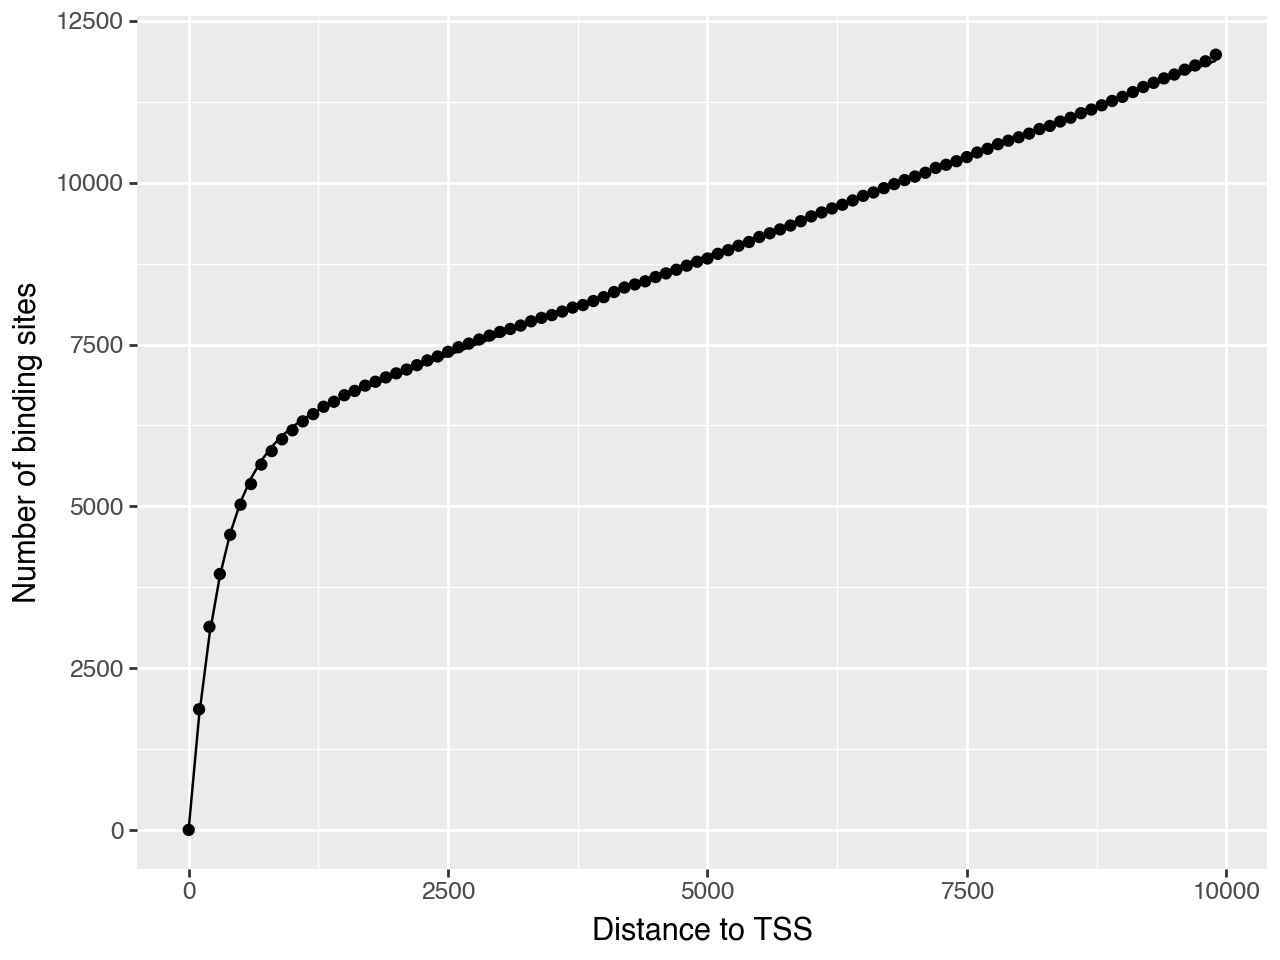

In [6]:
## Plot the empirical cumulative distribution and test model fit
(ggplot(summary)
+geom_point(aes(x = 'interval', y = 'cumulative'))
+geom_line(aes(x = 'interval', y = 'Predicted'))
+xlab('Distance to TSS')
+ylab('Number of binding sites'))

## Step 3: Calculate the distance threshold based on model parameters

In [7]:
spurious_to_true_ratio = 0.1 #Set the spurious to functional binding rate 
threshold = n_max_true(parameters[0],parameters[1],parameters[2], [spurious_to_true_ratio])
threshold

,Distance,Alpha
0,901,0.099976


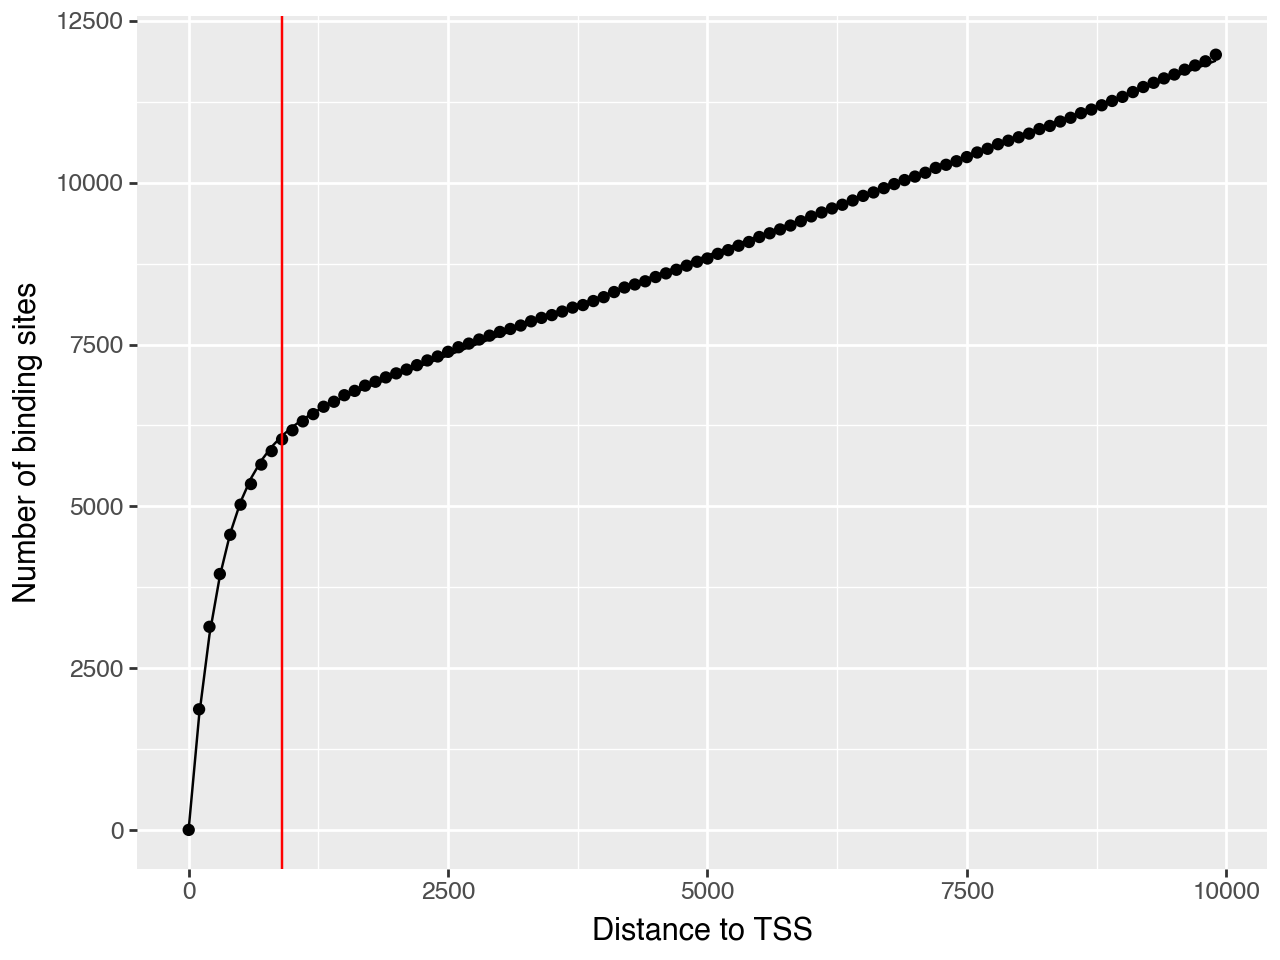

In [8]:
## Plot the empirical cumulative distribution and test model fit
(ggplot(summary)
+geom_point(aes(x = 'interval', y = 'cumulative'))
+geom_line(aes(x = 'interval', y = 'Predicted'))
+geom_vline(xintercept = threshold.Distance.values[0], color = 'red')
+xlab('Distance to TSS')
+ylab('Number of binding sites'))

## Step 4: Save functional targets and biologically relevant peaks

In [9]:
bed_file_functional = bed_file.loc[bed_file.min_dist <= threshold.Distance.values[0],['chrom', 'start','end','Gene']]
bed_file_functional.to_csv('example_functional_targets.bed', sep = '\t', header = 'None', index = None)
bed_file_functional

,chrom,start,end,Gene
1,chr12,53324768,53325052,AAAS
2,chr12,125065239,125065432,AACS
3,chr9,96655004,96655264,AAED1
4,chr11,77820650,77821048,AAMDC
5,chr2,218270057,218270285,AAMP
...,...,...,...,...
12117,chr1,52842629,52842895,ZYG11A
12118,chr7,143380217,143380593,ZYX
12119,chr1,77682528,77682778,ZZZ3
12120,chr1,77683376,77683688,ZZZ3
